# Whisper SER Evaluation
This notebook evaluates [`firdhokk/speech-emotion-recognition-with-openai-whisper-large-v3`](https://huggingface.co/firdhokk/speech-emotion-recognition-with-openai-whisper-large-v3) on the local IEMOCAP metadata using the same style as the `feature_selection` notebooks: a stratified `80/20` split, readable section outputs, metrics tables, confusion matrix, and saved artifacts.


## 1) Imports and Notebook Settings
This cell loads dependencies, configures plotting, and prints environment details so we can quickly sanity-check the runtime before loading the model.


In [1]:
from pathlib import Path
import json

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

plt.style.use('ggplot')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
np.random.seed(42)

print('Imports loaded.')
print(f'Torch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')


Imports loaded.
Torch version: 2.10.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5080


## 2) Configuration
These settings mirror the newer `feature_selection` notebooks while restricting evaluation to labels that map cleanly between IEMOCAP and the Whisper checkpoint.


In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root from the notebook location.')


if 'whisper' in str(Path.cwd()).replace('\\', '/').lower():
    REPO_ROOT = find_repo_root(Path.cwd().resolve())
else:
    REPO_ROOT = Path.cwd().resolve()

MODEL_ID = 'firdhokk/speech-emotion-recognition-with-openai-whisper-large-v3'
TARGET_LABELS = ['ang', 'fea', 'hap', 'neu', 'sad', 'sur']
TEST_SIZE = 0.20
RANDOM_STATE = 42
BATCH_SIZE = 4
MAX_DURATION = 30.0
LIMIT_TEST_ROWS = None
OUTPUT_DIR = REPO_ROOT / 'whisper' / 'evaluation' / 'artifacts' / 'whisper_large_v3_iemocap_clean_6way'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IEMOCAP_TO_EVAL_LABEL = {
    'ang': 'ang',
    'fea': 'fea',
    'hap': 'hap',
    'neu': 'neu',
    'sad': 'sad',
    'sur': 'sur',
}

MODEL_TO_IEMOCAP_LABEL = {
    'angry': 'ang',
    'disgust': 'dis',
    'fearful': 'fea',
    'happy': 'hap',
    'neutral': 'neu',
    'sad': 'sad',
    'surprised': 'sur',
}

config_df = pd.DataFrame([
    ('repo_root', str(REPO_ROOT)),
    ('model_id', MODEL_ID),
    ('target_labels', ', '.join(TARGET_LABELS)),
    ('test_size', TEST_SIZE),
    ('random_state', RANDOM_STATE),
    ('batch_size', BATCH_SIZE),
    ('max_duration', MAX_DURATION),
    ('limit_test_rows', LIMIT_TEST_ROWS),
    ('output_dir', str(OUTPUT_DIR)),
], columns=['setting', 'value'])

display(config_df)
print('IEMOCAP label policy:', IEMOCAP_TO_EVAL_LABEL)
print('Model-to-IEMOCAP prediction mapping:', MODEL_TO_IEMOCAP_LABEL)


,setting,value
0,repo_root,/mnt/f/Speech-Emotion-Recognition
1,model_id,firdhokk/speech-emotion-recognition-with-opena...
2,target_labels,"ang, fea, hap, neu, sad, sur"
3,test_size,0.2
4,random_state,42
5,batch_size,4
6,max_duration,30.0
7,limit_test_rows,None
8,output_dir,/mnt/f/Speech-Emotion-Recognition/whisper/eval...


IEMOCAP label policy: {'ang': 'ang', 'fea': 'fea', 'hap': 'hap', 'neu': 'neu', 'sad': 'sad', 'sur': 'sur'}
Model-to-IEMOCAP prediction mapping: {'angry': 'ang', 'disgust': 'dis', 'fearful': 'fea', 'happy': 'hap', 'neutral': 'neu', 'sad': 'sad', 'surprised': 'sur'}


## 3) Load IEMOCAP Metadata and Build the Evaluation Label Space
This section loads the repo metadata, keeps only clean label overlaps, checks that audio files exist, and shows the class distribution that will actually be evaluated.


In [3]:
METADATA_PATH = REPO_ROOT / 'datasets' / 'IEMOCAP' / 'iemocap_full_dataset.csv'
AUDIO_ROOT = REPO_ROOT / 'datasets' / 'IEMOCAP'

if not METADATA_PATH.exists():
    raise FileNotFoundError(f'Metadata CSV not found: {METADATA_PATH}')

raw_df = pd.read_csv(METADATA_PATH)
raw_df['emotion'] = raw_df['emotion'].astype(str).str.strip().str.lower()
raw_df['method'] = raw_df['method'].astype(str).str.strip().str.lower()
raw_df['gender'] = raw_df['gender'].astype(str).str.strip().str.upper()
raw_df['path'] = raw_df['path'].astype(str).str.replace('\\', '/', regex=False).str.strip()

work_df = raw_df[raw_df['emotion'].isin(IEMOCAP_TO_EVAL_LABEL)].copy()
work_df = work_df[work_df['agreement'] > 0].copy()
work_df['eval_label'] = work_df['emotion'].map(IEMOCAP_TO_EVAL_LABEL)
work_df['audio_path'] = work_df['path'].map(lambda rel: str((AUDIO_ROOT / rel).resolve()))
work_df['audio_exists'] = work_df['audio_path'].map(lambda p: Path(p).exists())
work_df = work_df[work_df['audio_exists']].reset_index(drop=True)

if work_df.empty:
    raise RuntimeError('No rows remained after filtering. Check the metadata path and label policy.')

print(f'Raw metadata rows: {len(raw_df):,}')
print(f'Rows after label/agreement/audio filtering: {len(work_df):,}')
print('Original emotion distribution after filtering:')
display(work_df['emotion'].value_counts().rename_axis('emotion').reset_index(name='count'))
print('Evaluation label distribution:')
display(work_df['eval_label'].value_counts().rename_axis('eval_label').reset_index(name='count'))
print('Session distribution:')
display(work_df['session'].value_counts().sort_index().rename_axis('session').reset_index(name='count'))

display(work_df[['session', 'method', 'gender', 'emotion', 'eval_label', 'path']].head(10))


Raw metadata rows: 10,039
Rows after label/agreement/audio filtering: 4,637
Original emotion distribution after filtering:


,emotion,count
0,neu,1708
1,ang,1103
2,sad,1084
3,hap,595
4,sur,107
5,fea,40


Evaluation label distribution:


,eval_label,count
0,neu,1708
1,ang,1103
2,sad,1084
3,hap,595
4,sur,107
5,fea,40


Session distribution:


,session,count
0,1,979
1,2,839
2,3,1030
3,4,819
4,5,970


,session,method,gender,emotion,eval_label,path
0,1,script,F,neu,neu,Session1/sentences/wav/Ses01F_script02_1/Ses01...
1,1,script,F,sur,sur,Session1/sentences/wav/Ses01F_script02_1/Ses01...
2,1,script,F,neu,neu,Session1/sentences/wav/Ses01F_script02_1/Ses01...
3,1,script,F,ang,ang,Session1/sentences/wav/Ses01F_script02_1/Ses01...
4,1,script,F,ang,ang,Session1/sentences/wav/Ses01F_script02_1/Ses01...
5,1,script,F,neu,neu,Session1/sentences/wav/Ses01F_script02_1/Ses01...
6,1,script,F,hap,hap,Session1/sentences/wav/Ses01F_script02_1/Ses01...
7,1,script,F,sad,sad,Session1/sentences/wav/Ses01F_script02_1/Ses01...
8,1,script,F,neu,neu,Session1/sentences/wav/Ses01F_script02_1/Ses01...
9,1,script,F,neu,neu,Session1/sentences/wav/Ses01F_script02_1/Ses01...


## 4) Train/Test Split
This uses the same stratified `train_test_split` style as the `feature_selection` notebooks and prints the resulting train/test shapes and class balance.


In [4]:
train_df, test_df = train_test_split(
    work_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=work_df['eval_label'],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

if LIMIT_TEST_ROWS is not None:
    test_df = test_df.iloc[:LIMIT_TEST_ROWS].reset_index(drop=True)

print(f'Train rows: {len(train_df):,}')
print(f'Test rows:  {len(test_df):,}')
print('Train label distribution:')
display(train_df['eval_label'].value_counts().rename_axis('eval_label').reset_index(name='count'))
print('Test label distribution:')
display(test_df['eval_label'].value_counts().rename_axis('eval_label').reset_index(name='count'))


Train rows: 3,709
Test rows:  928
Train label distribution:


,eval_label,count
0,neu,1366
1,ang,882
2,sad,867
3,hap,476
4,sur,86
5,fea,32


Test label distribution:


,eval_label,count
0,neu,342
1,ang,221
2,sad,217
3,hap,119
4,sur,21
5,fea,8


## 5) Load the Whisper SER Checkpoint
This cell downloads the feature extractor and model, resolves the active device, and shows the native output labels of the checkpoint before we map them back into the repo's label space.


In [5]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_ID, do_normalize=True)
model = AutoModelForAudioClassification.from_pretrained(MODEL_ID)
model = model.to(DEVICE)
model.eval()

native_label_df = pd.DataFrame([
    {
        'model_label_id': int(idx),
        'model_label': label,
        'mapped_repo_label': MODEL_TO_IEMOCAP_LABEL.get(label, 'unmapped'),
    }
    for idx, label in model.config.id2label.items()
]).sort_values('model_label_id').reset_index(drop=True)

print(f'Device: {DEVICE}')
print(f'Feature extractor sample rate: {feature_extractor.sampling_rate}')
print(f'Number of model labels: {len(native_label_df)}')
display(native_label_df)


Loading weights:   0%|          | 0/491 [00:00<?, ?it/s]

Device: cuda
Feature extractor sample rate: 16000
Number of model labels: 7


,model_label_id,model_label,mapped_repo_label
0,0,angry,ang
1,1,disgust,dis
2,2,fearful,fea
3,3,happy,hap
4,4,neutral,neu
5,5,sad,sad
6,6,surprised,sur


## 6) Inference Helpers
This section defines the helper functions used for audio loading, batched inference, metric computation, and confusion-matrix plotting.


In [6]:
def load_audio(audio_path: Path, target_sr: int, max_duration: float) -> np.ndarray:
    audio, _ = librosa.load(audio_path, sr=target_sr, mono=True)
    max_length = int(target_sr * max_duration)
    if len(audio) >= max_length:
        return audio[:max_length].astype(np.float32, copy=False)

    padded = np.zeros(max_length, dtype=np.float32)
    padded[: len(audio)] = audio.astype(np.float32, copy=False)
    return padded


def batched(items, batch_size: int):
    for start in range(0, len(items), batch_size):
        yield items[start:start + batch_size]


def run_inference(frame: pd.DataFrame) -> tuple[list[str], np.ndarray]:
    audio_paths = [Path(p) for p in frame['audio_path'].tolist()]
    pred_labels = []
    probs_all = []

    with torch.inference_mode():
        for chunk in tqdm(list(batched(audio_paths, BATCH_SIZE)), desc='whisper inference', leave=False):
            batch_audio = [
                load_audio(path, target_sr=feature_extractor.sampling_rate, max_duration=MAX_DURATION)
                for path in chunk
            ]
            features = feature_extractor(
                batch_audio,
                sampling_rate=feature_extractor.sampling_rate,
                truncation=True,
                max_length=int(feature_extractor.sampling_rate * MAX_DURATION),
                padding=True,
                return_tensors='pt',
            )
            features = {key: value.to(DEVICE) for key, value in features.items()}
            logits = model(**features).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            pred_ids = logits.argmax(dim=-1).cpu().tolist()

            pred_labels.extend(model.config.id2label[int(idx)] for idx in pred_ids)
            probs_all.extend(probs)

    return pred_labels, np.vstack(probs_all)


def compute_metrics(y_true: list[str], y_pred: list[str]) -> dict[str, float]:
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision_weighted': float(precision_score(y_true, y_pred, average='weighted', labels=TARGET_LABELS, zero_division=0)),
        'recall_weighted': float(recall_score(y_true, y_pred, average='weighted', labels=TARGET_LABELS, zero_division=0)),
        'f1_weighted': float(f1_score(y_true, y_pred, average='weighted', labels=TARGET_LABELS, zero_division=0)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro', labels=TARGET_LABELS, zero_division=0)),
    }


def plot_confusion(y_true: list[str], y_pred: list[str], title: str):
    extra_pred_labels = sorted(label for label in set(y_pred) if label not in TARGET_LABELS)
    labels = [*TARGET_LABELS, *extra_pred_labels]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()


## 7) Run Whisper Evaluation on the Test Split
This is the main evaluation pass. It runs the model on the held-out test set, shows a preview of predictions, and summarizes the final metrics in the same style as the other notebooks.


In [7]:
native_pred_labels, probability_array = run_inference(test_df)
mapped_pred_labels = [MODEL_TO_IEMOCAP_LABEL.get(label, 'unmapped') for label in native_pred_labels]

y_true = test_df['eval_label'].tolist()
y_pred = mapped_pred_labels

metrics = compute_metrics(y_true, y_pred)
results_df = pd.DataFrame([
    {
        'stage': 'test',
        'model': 'whisper_large_v3_ser',
        'test_rows': int(len(test_df)),
        **metrics,
    }
])

probability_cols = {
    f"prob_{MODEL_TO_IEMOCAP_LABEL.get(model.config.id2label[int(idx)], model.config.id2label[int(idx)])}": probability_array[:, idx]
    for idx in range(probability_array.shape[1])
}

predictions_df = test_df[['session', 'method', 'gender', 'emotion', 'eval_label', 'path', 'audio_path']].copy()
predictions_df['pred_model_label_native'] = native_pred_labels
predictions_df['pred_eval_label'] = mapped_pred_labels
for col_name, values in probability_cols.items():
    predictions_df[col_name] = values

print('Test metrics:')
display(results_df)
print('Prediction preview:')
display(predictions_df.head(12))


whisper inference:   0%|          | 0/232 [00:00<?, ?it/s]

Test metrics:


,stage,model,test_rows,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
0,test,whisper_large_v3_ser,928,0.273707,0.574148,0.273707,0.248228,0.214845


Prediction preview:


,session,method,gender,emotion,eval_label,path,audio_path,pred_model_label_native,pred_eval_label,prob_ang,prob_dis,prob_fea,prob_hap,prob_neu,prob_sad,prob_sur
0,4,impro,F,ang,ang,Session4/sentences/wav/Ses04F_impro05/Ses04F_i...,/mnt/f/Speech-Emotion-Recognition/datasets/IEM...,surprised,sur,0.000861,0.000362,0.014088,0.032920,0.001025,0.000652,0.950092
1,4,script,F,hap,hap,Session4/sentences/wav/Ses04F_script01_3/Ses04...,/mnt/f/Speech-Emotion-Recognition/datasets/IEM...,happy,hap,0.000156,0.000309,0.000366,0.984699,0.001634,0.011945,0.000892
2,5,impro,M,neu,neu,Session5/sentences/wav/Ses05M_impro07/Ses05M_i...,/mnt/f/Speech-Emotion-Recognition/datasets/IEM...,sad,sad,0.000073,0.000122,0.000123,0.000780,0.001901,0.996685,0.000316
3,1,script,F,neu,neu,Session1/sentences/wav/Ses01F_script01_3/Ses01...,/mnt/f/Speech-Emotion-Recognition/datasets/IEM...,fearful,fea,0.000102,0.000120,0.983830,0.000221,0.007554,0.007583,0.000591
4,4,script,F,ang,ang,Session4/sentences/wav/Ses04F_script02_1/Ses04...,/mnt/f/Speech-Emotion-Recognition/datasets/IEM...,fearful,fea,0.000196,0.000095,0.996195,0.002415,0.000163,0.000374,0.000562
5,5,script,M,ang,ang,Session5/sentences/wav/Ses05M_script03_2/Ses05...,/mnt/f/Speech-Emotion-Recognition/datasets/IEM...,fearful,fea,0.000082,0.000093,0.998960,0.000095,0.000095,0.000609,0.000067
6,4,impro,M,neu,neu,Session4/sentences/wav/Ses04M_impro05/Ses04M_i...,/mnt/f/Speech-Emotion-Recognition/datasets/IEM...,happy,hap,0.051832,0.001062,0.010627,0.865073,0.031721,0.038437,0.001248
7,5,script,M,sad,sad,Session5/sentences/wav/Ses05M_script01_1b/Ses0...,/mnt/f/Speech-Emotion-Recognition/datasets/IEM...,sad,sad,0.000121,0.000100,0.002597,0.000111,0.000684,0.996299,0.000088
8,1,impro,M,neu,neu,Session1/sentences/wav/Ses01M_impro03/Ses01M_i...,/mnt/f/Speech-Emotion-Recognition/datasets/IEM...,happy,hap,0.000081,0.000081,0.000088,0.998457,0.000140,0.000982,0.000171
9,1,impro,F,sad,sad,Session1/sentences/wav/Ses01F_impro06/Ses01F_i...,/mnt/f/Speech-Emotion-Recognition/datasets/IEM...,sad,sad,0.000111,0.000153,0.000363,0.002894,0.000622,0.995534,0.000324


## 8) Detailed Report and Confusion Matrix
This section prints the per-class report and plots the confusion matrix so we can see exactly where the Whisper checkpoint is succeeding or failing on IEMOCAP.


Classification report:


,precision,recall,f1-score,support
ang,0.928571,0.117647,0.208835,221.000000
fea,0.024590,0.375000,0.046154,8.000000
hap,0.181467,0.394958,0.248677,119.000000
neu,0.617647,0.061404,0.111702,342.000000
sad,0.427300,0.663594,0.519856,217.000000
sur,0.087838,0.619048,0.153846,21.000000
accuracy,0.273707,0.273707,0.273707,0.273707
macro avg,0.377902,0.371942,0.214845,928.000000
weighted avg,0.574148,0.273707,0.248228,928.000000


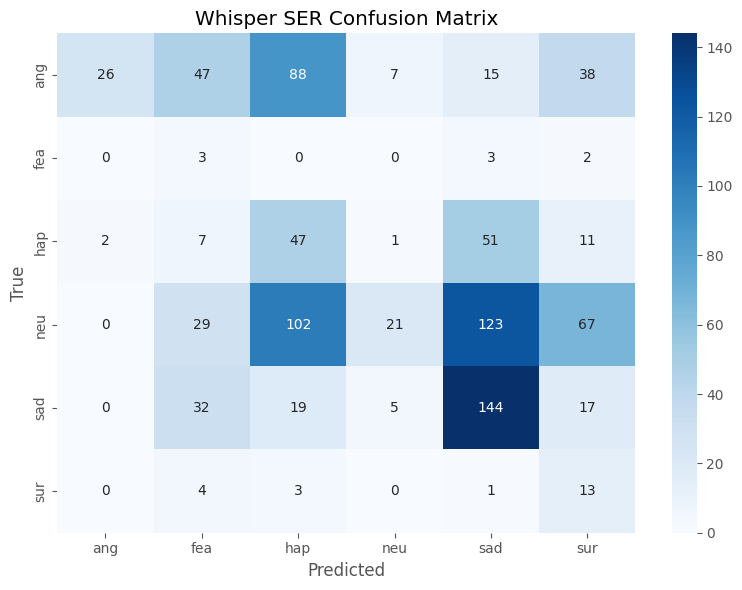

In [8]:
report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        labels=TARGET_LABELS,
        output_dict=True,
        zero_division=0,
    )
).transpose()

print('Classification report:')
display(report_df)
plot_confusion(y_true, y_pred, 'Whisper SER Confusion Matrix')


## 9) Save Artifacts
This exports the results table, test predictions, classification report, confusion matrix, and run metadata into `whisper/evaluation/artifacts`, matching the artifact-heavy workflow used elsewhere in the repo.


In [9]:
confusion_png_path = OUTPUT_DIR / 'confusion_matrix.png'
results_csv_path = OUTPUT_DIR / 'results.csv'
predictions_csv_path = OUTPUT_DIR / 'test_predictions.csv'
report_csv_path = OUTPUT_DIR / 'classification_report.csv'
metadata_json_path = OUTPUT_DIR / 'run_metadata.json'

results_df.to_csv(results_csv_path, index=False)
predictions_df.to_csv(predictions_csv_path, index=False)
report_df.to_csv(report_csv_path)

extra_pred_labels = sorted(label for label in set(y_pred) if label not in TARGET_LABELS)
labels = [*TARGET_LABELS, *extra_pred_labels]
cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Whisper SER Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
fig.tight_layout()
fig.savefig(confusion_png_path, dpi=160)
plt.close(fig)

run_metadata = {
    'model_id': MODEL_ID,
    'task': 'iemocap_whisper_ser_evaluation',
    'label_policy': {
        'iemocap_to_eval_label': IEMOCAP_TO_EVAL_LABEL,
        'model_to_iemocap_label': MODEL_TO_IEMOCAP_LABEL,
        'target_labels': TARGET_LABELS,
        'note': (
            'This notebook mirrors the feature_selection split-and-metrics workflow, '
            'using only the clean label overlaps between IEMOCAP and the upstream Whisper checkpoint. '
            'Excited, frustrated, other, xxx, and disgust are excluded.'
        ),
    },
    'split': {
        'test_size': TEST_SIZE,
        'random_state': RANDOM_STATE,
        'train_rows': int(len(train_df)),
        'test_rows': int(len(test_df)),
    },
    'inference': {
        'device': str(DEVICE),
        'batch_size': BATCH_SIZE,
        'max_duration': MAX_DURATION,
        'limit_test_rows': LIMIT_TEST_ROWS,
    },
    'metrics': metrics,
    'artifacts': {
        'results_csv': str(results_csv_path),
        'predictions_csv': str(predictions_csv_path),
        'classification_report_csv': str(report_csv_path),
        'confusion_matrix_png': str(confusion_png_path),
    },
}
metadata_json_path.write_text(json.dumps(run_metadata, indent=2), encoding='utf-8')

artifact_df = pd.DataFrame([
    ('results_csv', str(results_csv_path)),
    ('predictions_csv', str(predictions_csv_path)),
    ('classification_report_csv', str(report_csv_path)),
    ('confusion_matrix_png', str(confusion_png_path)),
    ('run_metadata_json', str(metadata_json_path)),
], columns=['artifact', 'path'])

display(artifact_df)


,artifact,path
0,results_csv,/mnt/f/Speech-Emotion-Recognition/whisper/eval...
1,predictions_csv,/mnt/f/Speech-Emotion-Recognition/whisper/eval...
2,classification_report_csv,/mnt/f/Speech-Emotion-Recognition/whisper/eval...
3,confusion_matrix_png,/mnt/f/Speech-Emotion-Recognition/whisper/eval...
4,run_metadata_json,/mnt/f/Speech-Emotion-Recognition/whisper/eval...


## 10) Notes
- This notebook follows the newer `feature_selection` notebooks by using a stratified 80/20 split rather than the older Session 5 holdout.
- It keeps only clean label overlaps: `ang`, `fea`, `hap`, `neu`, `sad`, and `sur`.
- It excludes `exc`, `fru`, `oth`, `xxx`, and `dis`.
- If you want a faster smoke run, set `LIMIT_TEST_ROWS` in the configuration cell.
